# Lab 8: Q-learning

## Frozen Lake

We will use the familiar Frozen Lake environment again.

To remind you what it is: It's a grid-world with a goal and a chance that you will slip and perform a random action. You cannot enter the wall and there are dangerous pits that terminate the episode with a large penalty.

In this lab, we will focus on Q-learning, which is a *off-policy* *model-free* algorithm.

**Question:** What is a off-policy algorithm?

**Question:** What is a model-free algorithm?

Let's update the FrozenLake to be a simulator - it will remember the position of the player and can sample the actions. The key methods are `reset()` and `step()`.

In [ ]:
import numpy as np, random
import matplotlib.pyplot as plt
from typing import List, Tuple

#set random seed.
random.seed(0)
np.random.seed(0)

example_map =  ["#########",
                "#       #",
                "#       #",
                "# ooooo #",
                "#   #  G#",
                "#########"]

# # = wall
# G = goal
# o = pit

Action = str # Action corresponds to a movement ['^', 'v', '<', '>'].
State = Tuple[int, int]  # State corresponds to a coordinate in the map.

class FrozenLakeEnv():
  ILLEGAL  = {"#"}
  TERMINAL = {"o", "G", "#"}
  REWARDS  = {
    "#": -0.1,
    " ": -0.1,
    "G":  1,
    "o": -10
    }
  MOVE_DIFFS = {
    '^': [-1,  0], # Move up.
    '<': [ 0, -1], # Move down.
    '>': [ 0,  1], # Move left.
    'v': [ 1,  0], # Move right.
    }

  def __init__(self, map: List[str], slip_probability: float):
    self.map = np.array([list(row) for row in map])
    self.init_state = np.where( self.map == "@" )   # find the player
    self.map[ self.init_state ] = " "               # remove the player

    self.slip_probability = slip_probability
    self.log_off()

  def reset(self):
    self.state = np.array( [self.init_state[0][0], self.init_state[1][0]] )
    self.terminated = False

    return self.state

  def actions(self) -> List[Action]:
    ''' Return all possible actions '''
    return list(self.MOVE_DIFFS.keys())


  def step(self, action: Action) -> Tuple[State, float, bool]:
    assert not self.terminated

    if np.random.rand() > self.slip_probability:
      s_ = self.state + self.MOVE_DIFFS[action]

    else:
      random_action = random.choice( self.actions() )
      s_ = self.state + self.MOVE_DIFFS[random_action]

    if self.map[s_[0], s_[1]] in self.ILLEGAL:
      s_ = self.state

    reward = self.REWARDS[ self.map[s_[0], s_[1]] ]
    done = self.map[s_[0], s_[1]] in self.TERMINAL

    if self.log:
      print(f"{self.state} + {action} => {s_}, r: {reward}, done: {done}")

    self.state = s_
    self.terminated = done

    return s_, reward, done

  def log_on(self):
    self.log = True

  def log_off(self):
    self.log = False

  def __str__(self):
    self.map_repr = self.map.copy()
    self.map_repr[self.state[0], self.state[1]] = "@"

    return "\n".join(["".join(row) for row in self.map_repr])

  def __repr__(self):
    return str(self)

In [ ]:
map = ["#########",
       "#       #",
       "#       #",
       "# ooooo #",
       "#@  #  G#",
       "#########"]

lake = FrozenLakeEnv(map, slip_probability=0.1)
lake.reset()
lake

## Q-learning

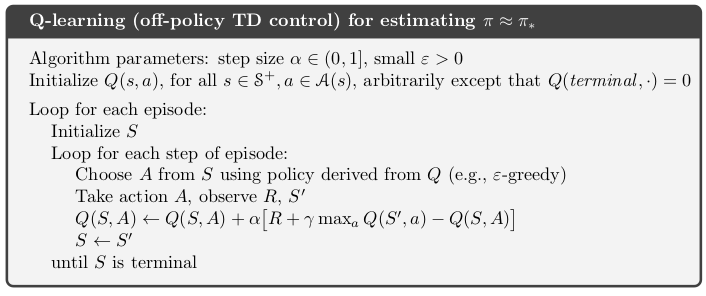

Since the states are positions in the maze, we will represent the Q function as a three dimensional array - a two-dimensional array for each action.

Note the similarity between this update of this Q-value and the exponential moving average in the multi-armed bandit problem.

**Question:** Can you explain the difference between those?
Below, implement an e-greedy policy and Q-learning.

In [ ]:
plt.rcParams['figure.figsize'] = [16, 10]

# Auxiliary method to plot the values. You can skip this.
def plot_q(q: np.array):
  fig, axs = plt.subplots(1, 4)

  actions = list(FrozenLakeEnv.MOVE_DIFFS.keys())

  for a, a_label in enumerate(actions):
    qa = q[a]
    ax = axs[a]
    ax.set_title(f"Action {a_label}")

    im = ax.imshow(qa, vmin=-2., vmax=1.)

    # Loop over data dimensions and create text annotations.
    for i in range(qa.shape[0]):
      for j in range(qa.shape[1]):
        text = ax.text(j, i, f"{qa[i, j]:.2f}", ha="center", va="center", color="w")

  plt.tight_layout()
  plt.show()

In [ ]:
class EpsilonGreedyPolicy():
  def __init__(self, epsilon):
    self.epsilon = epsilon

  def act(self, q, s):
    # Task:
    # - implement epsilon-greedy policy wrt. current q-function
    # - the correct indexing to q is q[action, s[0], s[1]]
    # - ou can use numpy's slicing; e.g., like this arr[:, 0]
    # - numpy has built-in functions for random numbers. np.random.rand() returns random real number in interval [0, 1) and np.rabdom.randint(A) returns random natural number in interval [0, A).
    # [student-only]
    raise NotImplementedError
    # [/student-only]

class QLearning():
  def __init__(self, env, exploration_policy, alpha, gamma):
    self.env = env
    self.exploration_policy = exploration_policy
    self.alpha_init = alpha
    self.gamma = gamma

    self.episode = 1
    self.q = np.zeros( (len(env.actions()), env.map.shape[0], env.map.shape[1]) )

  def get_alpha(self):
    return self.alpha_init

  def run(self, episodes, log_each=1):
    for episode in range(self.episode, self.episode + episodes):
      if episode % log_each == 0:
        print(f"Episode {episode}:")

      self.q = self.q_learning_single_episode(self.q)

      if episode % log_each == 0:
        plot_q(self.q)

      self.episode += 1

  def q_learning_single_episode(self, q):
    # Task:
    # - implement q-learning
    # - call self.get_alpha() to get the learning rate
    s = self.env.reset()
    done = False
    while not done:
      a = 0
      s = s_

    return q

Okay, let's try it!

In [ ]:
pi = EpsilonGreedyPolicy(0.1)
qlearning = QLearning(lake, pi, alpha=0.1, gamma=0.9)

lake.log_on()
qlearning.run(episodes=5)

Well, we can already say it's *extremely* sample-inefficient. We've run the algorithm for 5 full episodes, and it's still nowhere near convergence.

**Question:** Look at the episode 0, and the agent trajectory and explain the new values in the Q function.

**Questions:** Explain why the value of falling into the pit propagates to only a single state-action pair?


If we plot the graphs after each episode we would be here for a *very* long time. Let's speed it up a bit.

In [ ]:
lake.log_off()
qlearning.run(episodes=500, log_each=100)

Finally, some action! It seems that the agent found the gold at least in some trajectories. But the values look weird. It seems that they are not converging.

**Question:** Look at [3,7], right above the gold. Why is the value sometimes large and sometimes low?


The fundamental reason for the weird behaviour is because the convergence of Q learning is assured only under some conditions. They are:

- all states are visited infinitely often
- $\sum_{t} \alpha_t = \infty$
- $\sum_{t} \alpha_t^2 < \infty$

where $\alpha_t$ is the learning rate at step $t$.

**Question:** The first condition is already satisfied (asymptotically). Why?

However, the third condition is not met. We need to *anneal* the learning rate towards zero, while satisfying the second condition. Such annealing schedule is $\alpha_t = \min(\alpha_0, \frac{ \alpha_0}{k t})$, with some constant $k$. Let's implement it.

In [ ]:
class QLearningAnnealed(QLearning):
  def __init__(self, problem, exploration_policy, k, alpha, gamma):
    super().__init__(problem, exploration_policy, alpha, gamma)
    self.k = k

  def get_alpha(self):
   raise NotImplementedError

In [ ]:
pi = EpsilonGreedyPolicy(0.1)
qlearning = QLearningAnnealed(lake, pi, k=0.1, alpha=0.1, gamma=0.9)

qlearning.run(episodes=1000, log_each=100)

Okay, that seems like a good result!

**Question:** The $k$ is called a *hyperparameter*. We used $k=0.1$ why?

**Question:** Did we use any other hyperparameters?

**Question:** Given the Q values we just computed, how would we extract the value function? For reference, see the optimal value function (computed in the last lab) below.




*Optimal value:*

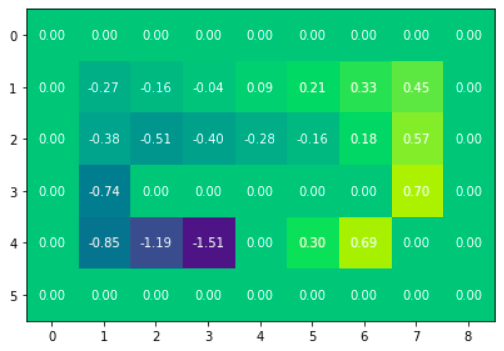

**Question:** If you compare the computed Q values with the optimal V values above, the Q values for [4, 5] and [4, 6] are missing (are 0). Why?

**Question:** Last time, when computing the value function with value iteration, we needed an expected return over all actions. Where did it go? Why don't we need it now?


**Bonus question:** In the q-learning algorithm, the values are updated only from the adjancent states. Hence, the rewards propagate rather slowly through the state space. Can you think about a way to speed it up?


## Task 2 - Deep Q-Learning (DQN)

So far, we have represented the Q-function as a table $Q[s, a]$. This works well when the state space is small and discrete. But what if the state space is continuous or very large?

**Deep Q-Network (DQN)** replaces the Q-table with a neural network that approximates the Q-function:
$$Q(s, a; \theta) \approx Q^*(s, a)$$

The network takes a state $s$ as input and outputs Q-values for all actions simultaneously.

### Key ideas in DQN

1. **Experience Replay** — transitions $(s, a, r, s')$ are stored in a replay buffer and sampled randomly for training. Helps with overfitting to specific paths and allows us to reuse previously seen data.
2. **Target Network** — a separate, periodically-updated copy of the network is used to compute the TD target $r + \gamma \max_{a'} Q(s', a'; \theta^-)$, stabilising training.
3. **Loss** — we minimise the mean squared error between our current network prediction and the target:
$$\mathcal{L}(\theta) = \mathbb{E}\left[\left(r + \gamma \max_{a'} Q(s', a'; \theta^-) - Q(s, a; \theta)\right)^2\right]$$

To be still able to train in short time, we will stick with FrozenLake and just scale up our environment.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

hard_map = [
    "#####################",
    "#@                G #",
    "#    oooo           #",
    "#    #              #",
    "#    #              #",
    "#    #              #",
    "#    #              #",
    "#    #              #",
    "#    #              #",
    "#    #              #",
    "#    #              #",
    "#    #              #",
    "#    #              #",
    "#                   #",
    "#####################",
]

env = FrozenLakeEnv(hard_map, slip_probability=0.1)

MAP_H, MAP_W = env.map.shape       # (15, 21)
N_ACTIONS    = len(env.actions())  # 4

**Question:** How do we pass our FrozenLake state to a neural network? What is a suitable representation and what is its dimensionality for our map?

First of all, we will implement the state representation.

In [ ]:
N_ACTIONS=4
STATE_DIM = 1 #TODO: Fill in the correct value


def encode_state(state: State) -> np.ndarray:
    """Encode (row, col) as concatenated one-hot vectors of length MAP_H + MAP_W."""
    # Task: create a float32 numpy vector of length STATE_DIM with one-hot encoding
    #       for the row and column of the state.
   raise NotImplementedError

init_state = env.reset()
print(env)
print(f"State: {init_state} is encoded as {encode_state(init_state)}")


Good! Now lets go through all the components we need for DQN.

In [ ]:

class ReplayBuffer:
    """A simple replay buffer, where we store transitions and sample them from it"""
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(self, state: np.ndarray, action: int, reward: float, next_state: np.ndarray, done: float) -> None:
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int) -> tuple:
        """Sample a batch size elements from the buffer """
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(np.array(states),      dtype=torch.float32),
            torch.tensor(actions,               dtype=torch.long),
            torch.tensor(rewards,               dtype=torch.float32),
            torch.tensor(np.array(next_states), dtype=torch.float32),
            torch.tensor(dones,                 dtype=torch.float32),
        )

    def __len__(self) -> int:
        return len(self.buffer)


**Question:** Why do we sample a `batch_size` of transitions from the replay buffer rather than learning from a single transition at a time?

And also our Q-function approximation network.

In [ ]:
#Fix the seed for reproducibility
torch.manual_seed(0)

class QNetwork(nn.Module):
    """A simple feedforward network approximating our Q-function"""
    def __init__(self, state_dim: int, n_actions: int, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

net = QNetwork(STATE_DIM, N_ACTIONS)
s = env.reset()
dummy = torch.tensor(encode_state(s)).unsqueeze(0)
print(f"Q-values for start state: {net(dummy)}")


And those are the components we need to implement our DQN agent with:
- $\varepsilon$-greedy action selection
- storing transitions in the replay buffer
- sampling a mini-batch and computing the MSE loss
- soft target network updates via exponential moving average (remember bandits/tabular Q-learning):
  $$\theta^- \leftarrow \tau\,\theta + (1 - \tau)\,\theta^-$$

Suggested hyperparameters to start with:

| Parameter | Value |
|---|---|
| `gamma` | 0.99 |
| `epsilon` | 0.1 |
| `lr` | 1e-3 |
| `batch_size` | 64 |
| `buffer_capacity` | 10 000 |
| `tau` (EMA coefficient) | 1e-3 |

In [ ]:
class DQNAgent:
    def __init__(self, env: FrozenLakeEnv, state_dim: int, n_actions: int,
                 gamma: float = 0.99, epsilon: float = 0.1,
                 lr: float = 1e-3, batch_size: int = 64,
                 buffer_capacity: int = 10_000, tau: float = 0.01):
        self.env        = env
        self.gamma      = gamma
        self.epsilon    = epsilon
        self.batch_size = batch_size
        self.tau        = tau

        self.online = QNetwork(state_dim, n_actions)
        self.target = QNetwork(state_dim, n_actions)
        self.target.load_state_dict(self.online.state_dict())
        self.target.eval()

        self.optimizer = optim.Adam(self.online.parameters(), lr=lr)
        self.buffer    = ReplayBuffer(buffer_capacity)

    def act(self, state: State) -> int:
        """Greedy action — picks the action with the highest Q-value."""
        with torch.no_grad():
            s = torch.tensor(encode_state(state)).unsqueeze(0)
            return self.online(s).argmax().item()

    def sample(self, state: State) -> int:
        """Epsilon-greedy action — used during training."""
        if np.random.rand() < self.epsilon:
            return np.random.randint(len(self.env.actions()))
        return self.act(state)

    def _update(self) -> None:
        """Sample a mini-batch, compute Bellman loss, and do a soft target update."""
        if len(self.buffer) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)

        # Q(s, a) from the online network
        q_values = self.online(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # r + gamma * max_a' Q_target(s', a')  (no gradient)
        with torch.no_grad():
            max_next_q = self.target(next_states).max(dim=1).values
            targets    = rewards + self.gamma * max_next_q * (1.0 - dones)

        loss = nn.functional.mse_loss(q_values, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Soft target update: theta_target <- tau * theta + (1 - tau) * theta_target
        for p_online, p_target in zip(self.online.parameters(), self.target.parameters()):
            p_target.data.copy_(self.tau * p_online.data + (1.0 - self.tau) * p_target.data)

        return loss.item()

    def run_episode(self) -> float:
        """Run one full episode; return total undiscounted return."""
        s    = self.env.reset()
        done = False
        total_return = 0.0
        while not done:
            a               = self.sample(s)
            s_next, r, done = self.env.step(self.env.actions()[a])
            self.buffer.push(encode_state(s), a, r, encode_state(s_next), float(done))
            self._update()
            total_return += r
            s = s_next
        return total_return


**Question:** The learning rate `lr` corresponds to $\alpha$ in the tabular setting. We discussed annealing $\alpha$ to guarantee convergence. Why we dont do that here?

Now lets train it!

In [ ]:
agent = DQNAgent(env, STATE_DIM, N_ACTIONS)
n_episodes = 200
returns    = []

for ep in range(n_episodes):
    returns.append(agent.run_episode())
    print(f"Finished episode {ep + 1}")

window   = 30
smoothed = np.convolve(returns, np.ones(window) / window, mode='valid')


#We plot the returns obtained in each episode, as well as a smoothed
# average
plt.figure()
plt.plot(returns, alpha=0.3, label='episode return')
plt.plot(np.arange(window - 1, n_episodes), smoothed, label=f'{window}-ep moving avg')
plt.xlabel('Episode')
plt.ylabel('Return')
plt.title('DQN on FrozenLake (hard map)')
plt.legend()
plt.tight_layout()
plt.show()


The returns are going up, so it is clearly learning something. It still sometimes "jumps" even in the later episodes though. Lets have a look at the learned Q-values and policy.

In [ ]:
def plot_q_dqn(agent: DQNAgent, vmin: float = None, vmax: float = None) -> None:
    """Plot Q(s, a) for each action as a separate heatmap, mirroring the tabular plot_q."""
    m = agent.env.map
    H, W = m.shape
    actions = agent.env.actions()

    # Build Q-value grids: one per action
    q_grids = np.full((len(actions), H, W), np.nan)
    for r in range(H):
        for c in range(W):
            if m[r, c] not in agent.env.ILLEGAL:
                with torch.no_grad():
                    x = torch.tensor(encode_state((r, c))).unsqueeze(0)
                    q_vals = agent.online(x).squeeze().numpy()
                for a in range(len(actions)):
                    q_grids[a, r, c] = q_vals[a]

    # Shared color range across all plots
    if vmin is None:
        vmin = np.nanmin(q_grids)
    if vmax is None:
        vmax = np.nanmax(q_grids)

    for a, a_label in enumerate(actions):
        qa = q_grids[a]
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.set_title(f"Action {a_label}")
        im = ax.imshow(qa, vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax)

        for i in range(H):
            for j in range(W):
                if not np.isnan(qa[i, j]):
                    ax.text(j, i, f"{qa[i, j]:.2f}", ha="center", va="center",
                            color="w", fontsize=7)

        plt.tight_layout()
        plt.show()


def plot_greedy_policy(agent: DQNAgent) -> None:
    """Plot the greedy action per state as an arrow, on a max-Q heatmap background."""
    m = agent.env.map
    H, W = m.shape
    actions = agent.env.actions()

    q_max = np.full((H, W), np.nan)
    best_action = np.full((H, W), -1, dtype=int)

    for r in range(H):
        for c in range(W):
            if m[r, c] not in agent.env.ILLEGAL:
                with torch.no_grad():
                    x = torch.tensor(encode_state((r, c))).unsqueeze(0)
                    q_vals = agent.online(x).squeeze()
                    q_max[r, c] = q_vals.max().item()
                    best_action[r, c] = q_vals.argmax().item()

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(q_max, vmin=np.nanmin(q_max), vmax=np.nanmax(q_max))
    plt.colorbar(im, ax=ax, label='max Q(s, ·)')

    for r in range(H):
        for c in range(W):
            if m[r, c] in agent.env.ILLEGAL:
                continue
            elif m[r, c] == 'G':
                label = 'G'
            elif m[r, c] == 'o':
                label = 'o'
            else:
                label = actions[best_action[r, c]]
            ax.text(c, r, label, ha='center', va='center',
                    color='w', fontsize=9, fontweight='bold')

    ax.set_title('Greedy policy (arrows) on max Q-value background')
    plt.tight_layout()
    plt.show()


plot_q_dqn(agent)
plot_greedy_policy(agent)


**Question:** Do you see any problem with this policy? Does it explain the "jumps" in the reward plot? Is there an alternative policy?

How we might force the DQN to learn this? We could modify the reward! Such techniques are called **reward shaping**.

Lets just copy our agent and make it use some sort of reward shaping. We will make it dependent on our state, next_state, true reward and the environment.

In [ ]:
class DQNAgentShaped(DQNAgent):
    """DQNAgent with potential-based reward shaping.

    The shaped reward r' = r + shaping is used for learning,
    but run_episode returns the TRUE environment return for fair comparison.
    """

    def __init__(self, env: FrozenLakeEnv, state_dim: int, n_actions: int,
                 reward_shaping: callable, **kwargs):
        super().__init__(env, state_dim, n_actions, **kwargs)
        self.reward_shaping = reward_shaping

    def run_episode(self) -> float:
        s    = self.env.reset()
        done = False
        total_return = 0.0
        while not done:
            a               = self.sample(s)
            s_next, r, done = self.env.step(self.env.actions()[a])
            shaped_r = self.reward_shaping(self.env, s, s_next, r)
            self.buffer.push(encode_state(s), a, shaped_r, encode_state(s_next), float(done))
            self._update()
            total_return += r  # true env reward, not shaped
            s = s_next
        return total_return


**Question:** How would you design the reward shaping to make the agent take the long way around?

In [ ]:
def is_adjacent_to_pit(env: FrozenLakeEnv, r: int, c: int) -> bool:
    """Check if (r, c) has at least one neighboring cell that is a pit 'o'."""
    # Task: check the 4 neighbours of (r, c) and return True if any is 'o'
    raise NotImplementedError


def pit_border_shaping(env: FrozenLakeEnv, s: State, s_next: State, r: float) -> float:
    """Return shaped reward: penalize the agent for moving to a cell adjacent to a pit."""
    # Task: return r with a penalty of -1 if s_next is adjacent to a pit
    raise NotImplementedError


Lets try to train it now!

In [ ]:
shaped_agent = DQNAgentShaped(env, STATE_DIM, N_ACTIONS, reward_shaping=pit_border_shaping)
n_episodes = 200
shaped_returns = []

for ep in range(n_episodes):
    shaped_returns.append(shaped_agent.run_episode())
    print(f"Finished episode {ep + 1}")

window   = 30
smoothed = np.convolve(shaped_returns, np.ones(window) / window, mode='valid')

plt.figure()
plt.plot(shaped_returns, alpha=0.3, label='episode return')
plt.plot(np.arange(window - 1, n_episodes), smoothed, label=f'{window}-ep moving avg')
plt.xlabel('Episode')
plt.ylabel('Return (true reward)')
plt.title('DQN with pit-border shaping')
plt.legend()
plt.tight_layout()
plt.show()


The stochasticity at the end of training seems to be gone! Lets verify it.

In [ ]:
plot_q_dqn(shaped_agent)
plot_greedy_policy(shaped_agent)


Great! It really did learn what we wanted to. What about different reward shaping? We could try difference in Manhattan distance.

In [ ]:
GOAL = (1, 18)

def manhattan_distance(state: State) -> float:
    r, c = state
    return (abs(r - GOAL[0]) + abs(c - GOAL[1]))

def manhattan_shaping(env: FrozenLakeEnv, s: State, s_next: State, r: float) -> float:
    return r + ( manhattan_distance(s) - manhattan_distance(s_next))



**Question:** What sort of behavior would you expect?

In [ ]:
# Train DQN with Manhattan distance shaping
manhattan_agent = DQNAgentShaped(env, STATE_DIM, N_ACTIONS, reward_shaping=manhattan_shaping)
n_episodes = 200
manhattan_returns = []

for ep in range(n_episodes):
    manhattan_returns.append(manhattan_agent.run_episode())
    print(f"Finished episode {ep + 1}")

window   = 30
smoothed = np.convolve(manhattan_returns, np.ones(window) / window, mode='valid')

plt.figure()
plt.plot(manhattan_returns, alpha=0.3, label='episode return')
plt.plot(np.arange(window - 1, n_episodes), smoothed, label=f'{window}-ep moving avg')
plt.xlabel('Episode')
plt.ylabel('Return (true reward)')
plt.title('DQN with Manhattan distance shaping')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plot_q_dqn(manhattan_agent)
plot_greedy_policy(manhattan_agent)


As we expected, the agent is even more driven towards the shorter path.

**Question:** Why are the Q-values highest far from the goal and then decrease? Would the Manhattan reward shaping be a good choice in some other environment?

### Summary

**Reward shaping** is a powerful tool. It can:
- **Steer agent behavior** — e.g. the pit-border penalty made the agent prefer safe paths over risky ones.
- **Enable learning** in environments with sparse rewards, where the agent would otherwise rarely (or never) receive a useful signal.

However, it requires **careful design**. As we saw with the Manhattan distance shaping, a seemingly reasonable heuristic can actively push the agent toward danger, making performance worse than no shaping at all. The choice of shaping function encodes assumptions about what "good" behavior looks like — if those assumptions are wrong, the agent will learn the wrong thing.

## Task 3 - Stochastic BlockWorld and Q-learning

See https://cw.fel.cvut.cz/wiki/courses/zui/tasks/task2.

Task hints for tabular part:
- think about what is a state
- make sure that $Q(s, \cdot) = 0$ if $s$ is terminal
- you have to tune the hyperparameters
- make sure your method is robust, i.e., it performs well even when run repeatedly
- all you learned in this Lab should be enough to solve the task; you can't represent the Q function as a matrix though - what is a proper representation?

Task hints for DQN part:
- Think about how to send the state to a neural network
- The BlockWorld environment has a lot of states and getting a positive reward is rare. Think about a suitable reward-shaping to drive the search
- Stick with the provided network structure, optimizer and loss by default. They are sufficient to solve the task. You may still wish to tune other hyperparameters
- Start with small N. If your DQN cannot reliable solve N=3, it will not solve N=5 either.
- A good sanity check is that your episodes should be shorter with increasing training time, as the network learns how to act better instead of just randomly stumbling upon a solution.


## (Optional) Task 4 - On-Policy Reinforcement Learning




**Question:** What is policy?


On-Policy Learning:

On-policy reinforcement learning is a category of reinforcement learning algorithms where the policy being learned about and the policy used to make decisions are the same. This means that the agent learns from the actions it takes, rather than learning from actions it might have taken under a different policy. This approach ensures that the policy is evaluated and improved based on the experiences gathered by following it, leading to a direct feedback loop for policy enhancement.

Off-Policy Learning:

Off-policy reinforcement learning refers to a category of reinforcement learning algorithms where the policy being improved, known as the target policy, is different from the policy used to generate behavior, known as the behavior policy. This distinction allows the agent to learn from experiences gathered by exploring the environment using a potentially different policy than the one it aims to optimize. This approach provides the flexibility to learn about the optimal policy while following a more explorative or different policy for action selection.

**Question:** Is Q-Learning a on-policy or off-policy?


## SARSA  (State-Action-Reward-State-Action)

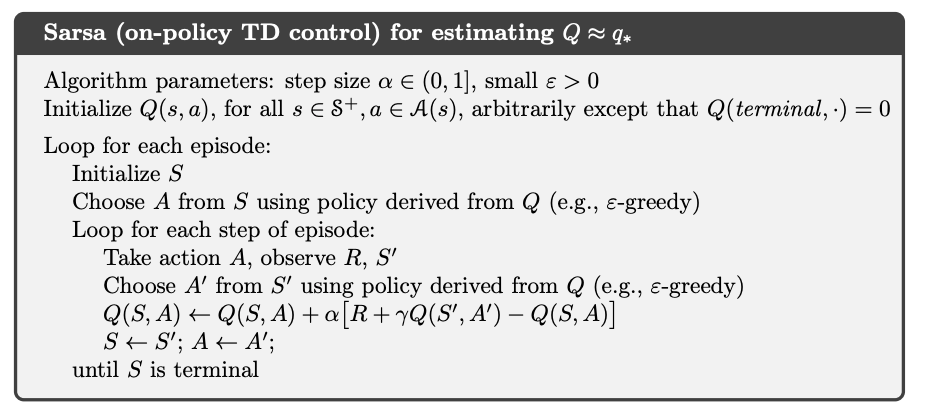

SARSA stands for State-Action-Reward-State-Action, and it is an on-policy reinforcement learning algorithm. This means that the policy the agent is currently following is the same policy that is being evaluated and improved. The acronym SARSA reflects the data used to update the value of a policy: the current state (S), the action (A) taken in that state, the reward (R) received after taking that action, the new state (S') arrived at after taking that action, and finally the next action (A') taken in the new state.

**Question:** What is the difference between SARSA and Q-Learning?


In [ ]:
class SARSA():
    def __init__(self, env, exploration_policy, k, alpha, gamma):
        self.env = env
        self.exploration_policy = exploration_policy
        self.alpha_init = alpha
        self.gamma = gamma
        self.k = k

        self.episode = 1
        self.q = np.zeros((len(env.actions()), env.map.shape[0], env.map.shape[1]))

    def get_alpha(self):
        return min( self.alpha_init, self.alpha_init / (self.k * self.episode) )

    def run(self, episodes, log_each=1):
        for episode in range(self.episode, self.episode + episodes):
            if episode % log_each == 0:
                print(f"Episode {episode}:")

            self.q = self.sarsa_single_episode(self.q)

            if episode % log_each == 0:
                plot_q(self.q)  # Ensure this function is defined elsewhere

            self.episode += 1

    def sarsa_single_episode(self, q):
        # Task:
        # - implement sarsa
        # - You can use the implementation of Q-Learning as a starting point
        # - call self.get_alpha() to get the learning rate

        s = self.env.reset()
#        # [student-only]
#        a = 0
#        # [/student-only
        done = False
        while not done:
            s_, r, done = self.env.step(self.env.actions()[a])
#            # [student-only]
#            a_ = 0
#            # [/student-only]
            s, a = s_, a_  # Update state and action for the next iteration

        return q

In [ ]:
pi = EpsilonGreedyPolicy(0.1)
sarsa = SARSA(lake, pi, k=0.1, alpha=0.1, gamma=0.9)

lake.log_off()
sarsa.run(episodes=500, log_each=100)

Let's increase the frozen lake size and run both Q-Learning and SARSA on the new map.

In [ ]:
map = ["#########",
       "#       #",
       "#       #",
       "#       #",
       "# ooooo #",
       "#@  #  G#",
       "#########"]

lake = FrozenLakeEnv(map, slip_probability=0.1)
lake.reset()
lake

In [ ]:
pi = EpsilonGreedyPolicy(0.1)
qlearning = QLearningAnnealed(lake, pi, k=0.1, alpha=0.1, gamma=0.9)

lake.log_off()
qlearning.run(episodes=500, log_each=100)

In [ ]:
pi = EpsilonGreedyPolicy(0.1)
sarsa = SARSA(lake, pi, k=0.1, alpha=0.1, gamma=0.9)

lake.log_off()
sarsa.run(episodes=1000, log_each=100)

**Question:** What's the difference between the policies learned from Q-Learning and SARSA?
